In [1]:
# Import standard libraries
import os

# Third-Party Libraries
import numpy as np
import matplotlib.pyplot as plt

# Import the Swarm Systems Lab Simulator
from ssl_simulator import SimulationEngine, load_sim, add_src_to_path
from ssl_simulator.robot_models import Unicycle2D
from ssl_simulator.visualization import set_paper_parameters
set_paper_parameters(fontsize=15)

from ssl_simulator.components.gvf import GvfLine

# -------------------------------------------------------------------------------------
# Import custom functions and classes (src in path is requiered)
add_src_to_path("", deep=0)

from sim_core.visualization import PlotBasicGvfIKCBF
from sim_core.controllers import GvfIK_CBF

# -------------------------------------------------------------------------------------
# Define constants for file paths
OUTPUT_DIR = os.path.join("..", "output")
SIMDATA_FILE = os.path.join(OUTPUT_DIR, "data.csv")

# GVF-IK for path following with induced oscillations

## Line $N = 3$

In [8]:
# Define the initial state
p = np.array([[10,10], [50,30], [70,-25], [120,-10], [220,10]])
speed = np.array([14, 4, 8, 2, 2])
speed = np.array([14, 0, 0, 0, 0])
theta = np.array([np.pi/4, -np.pi/4, np.pi/4, np.pi/6, -1.9*np.pi/2])

N = p.shape[0]

x0 = [p, speed, theta]

# --------------------------------
# Generate the trajectory to be followed
m, a = 0, 0
gvf_traj = GvfLine(m, a, line_length=350)

# Select the robot model
robot_model = Unicycle2D(x0)

# Initialize the controller
s, ke, kn = 1, 0.4, 1
controller = GvfIK_CBF(gvf_traj, s, ke, kn, obstacles=[1,2,3,4], gamma=0.8, col_rad=10)

# Then, construct the Simulator Engine
dt = 0.01
simulator = SimulationEngine(robot_model, controller, time_step=dt, 
                             log_filename=SIMDATA_FILE, log_time_step=0.1)

# --------------------------------
# Run the simulation and save data
tf = 20

simulator.run(tf)
# --------------------------------

Running simulation: 100%|██████████| 2000/2000 [00:00<00:00, 9389.66it/s]


------------------ SETTINGS ------------------
gvf_traj:
  __class__: GvfLine
  __params__:
    m: 0
    b: 0
    line_length: 350
----------------------------------------------
------------------- DATA ---------------------
time: shape (201,)
p: shape (201, 5, 2)
speed: shape (201, 5)
theta: shape (201, 5)
p_dot: shape (201, 5, 2)
speed_dot: shape (201, 5)
theta_dot: shape (201, 5)
u: shape (201, 5)
s: shape (201,)
ke: shape (201,)
kn: shape (201,)
gamma: shape (201,)
col_rad: shape (201,)
phi: shape (201,)
e: shape (201,)
omega_d: shape (201, 5)
omega_ref: shape (201, 5)
lgh: shape (201, 5, 5)
lgh_all: shape (201, 5, 5)
----------------------------------------------


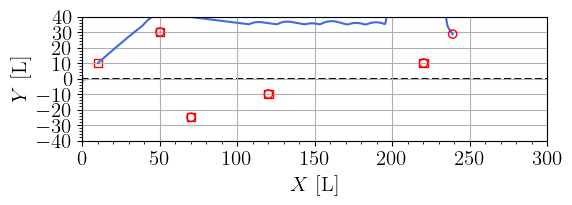

In [9]:
# Load previously saved simulation data from the specified file
simulation_data, settings = load_sim(SIMDATA_FILE, debug=True)

# Initialize the plotter with the loaded simulation data
plotter = PlotBasicGvfIKCBF(simulation_data, settings, 
                            xlims=[0, 300], ylims=[-40,40], max_major_ticks=5)

# Generate and display the plot
ax = plotter.plot(alpha=0.8)
plt.show()